<a href="https://colab.research.google.com/github/kingpentes/Kelompok6-deepLearning-tubes/blob/main/Kelompok6_DeepLearning_Potensi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**One For More Continual Diffusion Model (CDAD)**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install numpy==2.0.0 scipy==1.14.1 diffusers==0.30.0 transformers==4.44.0 accelerate==0.34.0 --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 6.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.8/60.8 kB 7.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.0/19.0 MB 80.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 MB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 89.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 105.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.3/324.3 kB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 47.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 104.0 MB/s eta 0:00:00


In [3]:
# import os
# from PIL import Image

# dataset_path1 = "/content/drive/MyDrive/deep_learning/tubes_DL/otak"
# dataset_path2 = "/content/drive/MyDrive/deep_learning/tubes_DL/rahim"

# def verifikasi_dataset_citra(path):
#     if not os.path.exists(path):
#         print(f"Folder '{path}' tidak ditemukan!")
#         return

#     gambar_rusak   = []
#     ekstensi_salah = []
#     gambar_valid   = []
#     ekstensi_valid = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
#     total_file     = 0

#     print(f"\n{'='*55}")
#     print(f"Memulai pengecekan: {path}")
#     print(f"{'='*55}")

#     for root, dirs, files in os.walk(path):
#         for file in files:
#             total_file += 1
#             filepath = os.path.join(root, file)
#             ext = os.path.splitext(file)[1].lower()

#             if ext not in ekstensi_valid:
#                 ekstensi_salah.append(filepath)
#                 continue

#             try:
#                 with Image.open(filepath) as img:
#                     img.verify()
#                 gambar_valid.append(filepath)
#             except Exception as e:
#                 gambar_rusak.append((filepath, str(e)))

#     # Laporan
#     print(f"\nLAPORAN HASIL")
#     print(f"  Total file ditemukan : {total_file}")
#     print(f"  Gambar valid         : {len(gambar_valid)}")
#     print(f"  Gambar rusak/corrupt : {len(gambar_rusak)}")
#     print(f"  File bukan gambar    : {len(ekstensi_salah)}")

#     # Rincian per subfolder
#     print(f"\n  Rincian per subfolder:")
#     subfolder_count = {}
#     for filepath in gambar_valid:
#         subfolder = os.path.basename(os.path.dirname(filepath))
#         subfolder_count[subfolder] = subfolder_count.get(subfolder, 0) + 1
#     for subfolder, count in sorted(subfolder_count.items()):
#         print(f"  └─ {subfolder:35s}: {count} gambar")

#     # Detail gambar rusak saja
#     if gambar_rusak:
#         print(f"\n  Daftar gambar rusak:")
#         for filepath, error in gambar_rusak:
#             print(f"  └─ {filepath}")
#             print(f"     Error: {error}")

#     if not gambar_rusak:
#         print(f"\n  Semua gambar aman dan valid!")

#     print(f"{'='*55}\n")

# verifikasi_dataset_citra(dataset_path1)
# verifikasi_dataset_citra(dataset_path2)

In [4]:
# #memisahkan data testing dan training
# from google.colab import drive
# import os
# import shutil

# base_path = '/content/drive/MyDrive/deep_learning/tubes_DL'

# # Source paths
# otak_path   = os.path.join(base_path, 'otak/brain_tumor_dataset')
# rahim_path  = os.path.join(base_path, 'rahim')

# # Destination paths
# train_tumor_path    = os.path.join(base_path, 'train_tumor')
# testing_otak_path   = os.path.join(base_path, 'testing_otak')
# train_rahim_path    = os.path.join(base_path, 'train_rahim')
# testing_rahim_path  = os.path.join(base_path, 'testing_rahim')

# # Buat folder tujuan jika belum ada
# for folder in [train_tumor_path, testing_otak_path, train_rahim_path, testing_rahim_path]:
#     os.makedirs(folder, exist_ok=True)
#     print(f" Folder siap: {folder}")

# IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.tif', '.gif', '.webp'}

# def copy_images(src_folder, dst_folder, label=""):
#     if not os.path.exists(src_folder):
#         print(f" Folder tidak ditemukan: {src_folder}")
#         return 0

#     count = 0
#     for filename in os.listdir(src_folder):
#         ext = os.path.splitext(filename)[1].lower()
#         if ext in IMAGE_EXTENSIONS:
#             src_file = os.path.join(src_folder, filename)
#             dst_file = os.path.join(dst_folder, filename)

#             # Hindari overwrite jika nama file sama
#             if os.path.exists(dst_file):
#                 name, extension = os.path.splitext(filename)
#                 dst_file = os.path.join(dst_folder, f"{name}_{label}{extension}")

#             shutil.copy2(src_file, dst_file)
#             count += 1

#     print(f"  {label}: {count} gambar disalin → {dst_folder}")
#     return count

# # PROSES OTAK
# print("\n Memproses folder OTAK...")

# # healthy → train_tumor
# copy_images(
#     src_folder = os.path.join(otak_path, 'healthy'),
#     dst_folder = train_tumor_path,
#     label      = 'healthy'
# )

# # glioma, meningioma, pituitary → testing_otak
# for folder_name in ['glioma', 'meningioma', 'pituitary']:
#     copy_images(
#         src_folder = os.path.join(otak_path, folder_name),
#         dst_folder = testing_otak_path,
#         label      = folder_name
#     )

# # PROSES RAHIM

# print("\n Memproses folder RAHIM...")

# # im_Superficial-Intermediate, im_Parabasal → train_rahim
# for folder_name in ['im_Superficial-Intermediate', 'im_Parabasal']:
#     copy_images(
#         src_folder = os.path.join(rahim_path, folder_name),
#         dst_folder = train_rahim_path,
#         label      = folder_name
#     )

# # Sisanya (im_Dyskeratotic, im_Koilocytotic, im_Metaplastic) → testing_rahim
# for folder_name in ['im_Dyskeratotic', 'im_Koilocytotic', 'im_Metaplastic']:
#     copy_images(
#         src_folder = os.path.join(rahim_path, folder_name),
#         dst_folder = testing_rahim_path,
#         label      = folder_name
#     )


# # RINGKASAN HASIL
# print("\n RINGKASAN:")
# for label, path in [
#     ('train_tumor',   train_tumor_path),
#     ('testing_otak',  testing_otak_path),
#     ('train_rahim',   train_rahim_path),
#     ('testing_rahim', testing_rahim_path),
# ]:
#     total = len([f for f in os.listdir(path) if os.path.splitext(f)[1].lower() in IMAGE_EXTENSIONS])
#     print(f"  {label:20s} → {total} gambar")

# print("\n Selesai!")

In [5]:
# import os, shutil

# def reorganize_folder(src_path, class_name="normal"):
#     """Pindahkan gambar langsung ke subfolder kelas jika belum terstruktur."""
#     # Cek apakah sudah ada subfolder
#     entries = os.listdir(src_path)
#     has_subdir = any(os.path.isdir(os.path.join(src_path, e)) for e in entries)

#     if not has_subdir:
#         print(f"  Reorganizing: {src_path}")
#         class_dir = os.path.join(src_path, class_name)
#         os.makedirs(class_dir, exist_ok=True)
#         for f in entries:
#             if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
#                 shutil.move(os.path.join(src_path, f),
#                             os.path.join(class_dir, f))
#         print(f"  ✓ Gambar dipindahkan ke subfolder '{class_name}'")

# # Jalankan sebelum buat_dataloader
# reorganize_folder(f'{BASE_PATH}/train_tumor',  class_name='normal')
# reorganize_folder(f'{BASE_PATH}/train_rahim',  class_name='normal')
# # Untuk test: sesuaikan class_name dengan label aslinya
# reorganize_folder(f'{BASE_PATH}/testing_otak',  class_name='tumor')
# reorganize_folder(f'{BASE_PATH}/testing_rahim', class_name='abnormal')

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import datasets, transforms

from diffusers import AutoencoderKL, UNet2DConditionModel, DDIMScheduler
from transformers import CLIPTextModel, CLIPTokenizer

print(f"numpy     : {np.__version__}")
import scipy, diffusers, accelerate
print(f"scipy     : {scipy.__version__}")
print(f"diffusers : {diffusers.__version__}")

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device    : {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU       : {torch.cuda.get_device_name(0)}")
    print(f"VRAM      : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

numpy     : 2.0.2
scipy     : 1.14.1
diffusers : 0.30.0
Device    : cuda
GPU       : Tesla T4
VRAM      : 15.6 GB



  TASK : OTAK  — Brain Tumor
  Kelas train      : ['normal']
  Kelas test       : ['anomaly', 'normal']
  Train (normal)   : 1600 gambar
  Val   (normal)   : 400 gambar
  Test  (anomali)  : 7023 gambar
  Batch size       : 8
  Pairs per batch  : (x_normal, x_perturbed)

  TASK : RAHIM — Cervical Cell
  Kelas train      : ['normal']
  Kelas test       : ['anomaly', 'normal']
  Train (normal)   : 1379 gambar
  Val   (normal)   : 344 gambar
  Test  (anomali)  : 4886 gambar
  Batch size       : 8
  Pairs per batch  : (x_normal, x_perturbed)


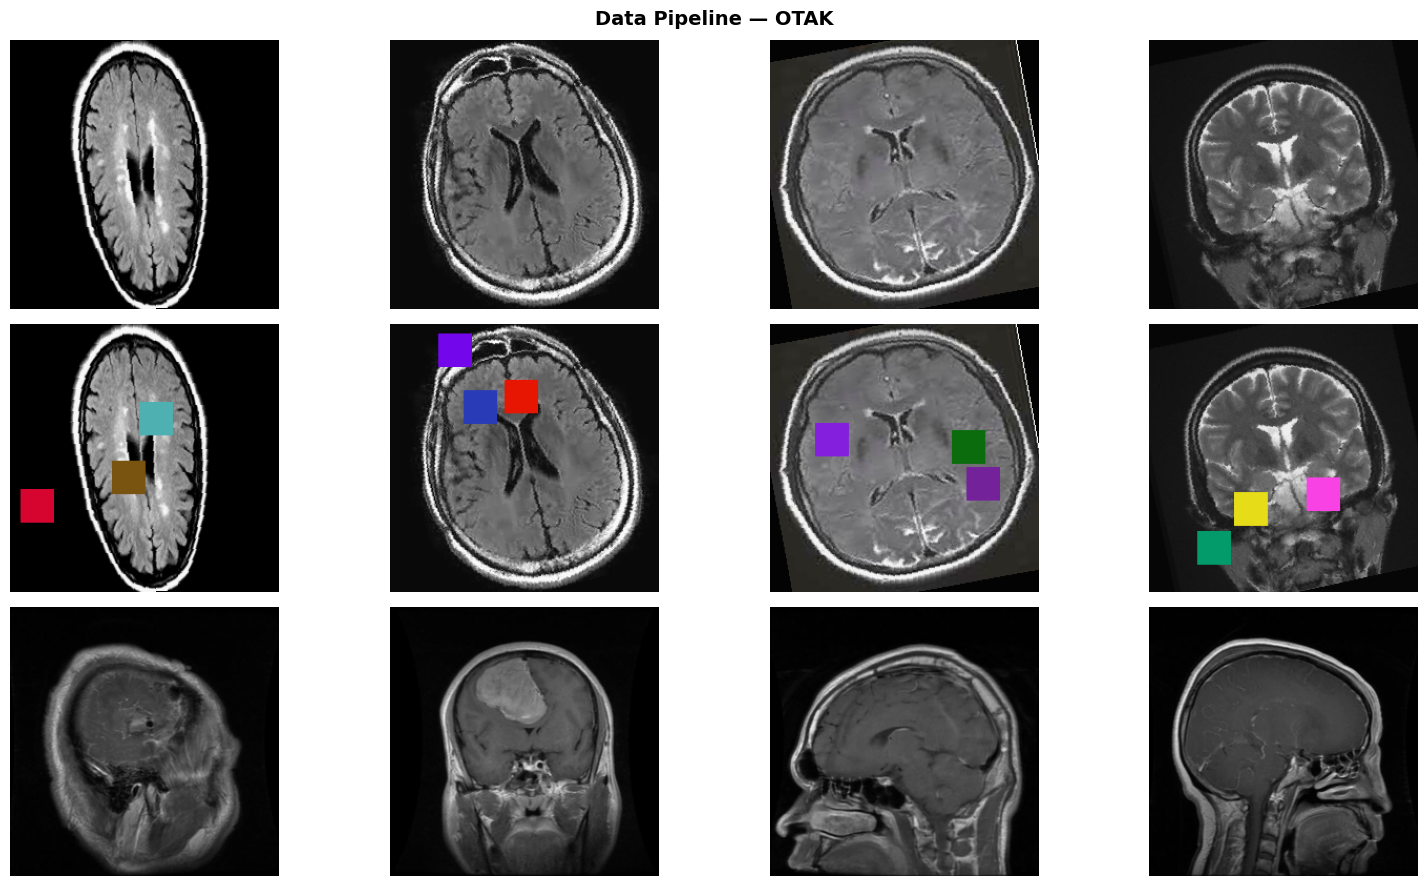

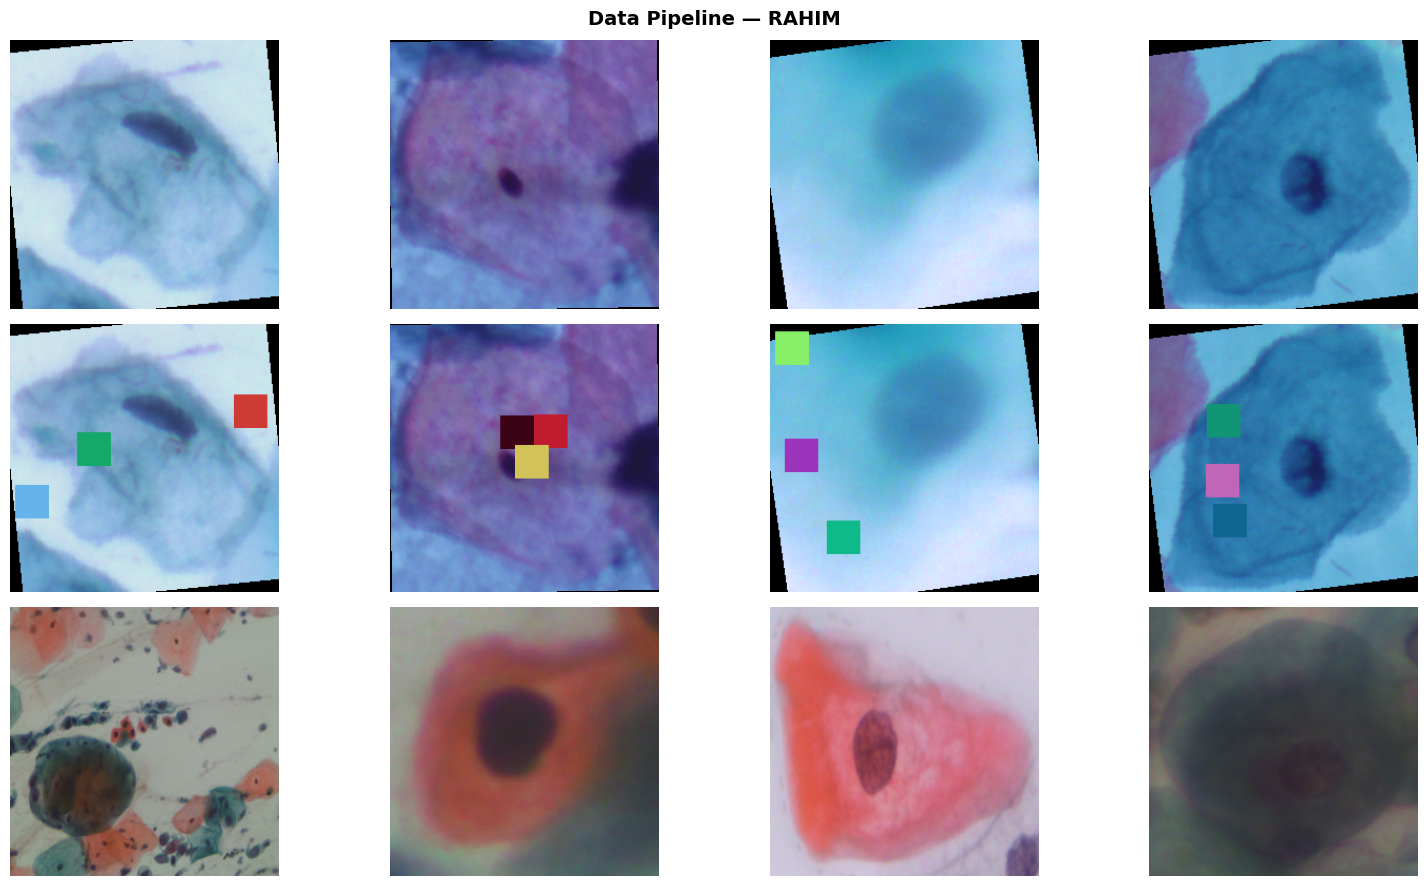

In [7]:
# DATA PIPELINE
# Input images di-resize ke 256x256

BASE_PATH  = '/content/drive/MyDrive/deep_learning/tubes_DL'
IMG_SIZE   = 256   # paper: "input images have all resized of 256x256"
BATCH_SIZE = 8
VAL_SPLIT  = 0.2
SEED       = 42

# Normalisasi ke [-1, 1]
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5],
                         [0.5, 0.5, 0.5])
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5],
                         [0.5, 0.5, 0.5])
])


class PatchPerturbation:
    def __init__(self, patch_size=32, num_patches=3):
        self.patch_size  = patch_size
        self.num_patches = num_patches

    def __call__(self, img_tensor):
        perturbed = img_tensor.clone()
        _, H, W   = img_tensor.shape
        for _ in range(self.num_patches):
            x = torch.randint(0, W - self.patch_size, (1,)).item()
            y = torch.randint(0, H - self.patch_size, (1,)).item()
            val = torch.rand(3, 1, 1) * 2 - 1
            perturbed[:, y:y+self.patch_size, x:x+self.patch_size] = val
        return perturbed

patch_perturb = PatchPerturbation(patch_size=32, num_patches=3)

class NormalAnomalyDataset(Dataset):
    def __init__(self, base_dataset):
        self.base = base_dataset

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        img, label = self.base[idx]
        perturbed  = patch_perturb(img)
        return img, perturbed, label

def buat_dataloader(train_path, test_path, nama_task):
    print(f"\n{'='*55}\n  TASK : {nama_task}\n{'='*55}")

    full_train = datasets.ImageFolder(train_path, transform=train_transform)
    n_val      = int(len(full_train) * VAL_SPLIT)
    n_train    = len(full_train) - n_val
    train_set, val_set = random_split(
        full_train, [n_train, n_val],
        generator=torch.Generator().manual_seed(SEED)
    )

    train_pair = NormalAnomalyDataset(train_set)
    val_pair   = NormalAnomalyDataset(val_set)
    test_set   = datasets.ImageFolder(test_path, transform=test_transform)

    train_loader = DataLoader(train_pair, batch_size=BATCH_SIZE,
                              shuffle=True,  num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_pair,   batch_size=BATCH_SIZE,
                              shuffle=False, num_workers=2, pin_memory=True)
    test_loader  = DataLoader(test_set,   batch_size=BATCH_SIZE,
                              shuffle=False, num_workers=2, pin_memory=True)

    print(f"  Kelas train      : {full_train.classes}")
    print(f"  Kelas test       : {test_set.classes}")
    print(f"  Train (normal)   : {n_train} gambar")
    print(f"  Val   (normal)   : {n_val} gambar")
    print(f"  Test  (anomali)  : {len(test_set)} gambar")
    print(f"  Batch size       : {BATCH_SIZE}")
    print(f"  Pairs per batch  : (x_normal, x_perturbed)")

    return train_loader, val_loader, test_loader

train_otak,  val_otak,  test_otak  = buat_dataloader(
    f'{BASE_PATH}/train_tumor',  f'{BASE_PATH}/testing_otak',  "OTAK  — Brain Tumor")
train_rahim, val_rahim, test_rahim = buat_dataloader(
    f'{BASE_PATH}/train_rahim',  f'{BASE_PATH}/testing_rahim', "RAHIM — Cervical Cell")

#  Visualisasi: normal vs perturbed vs test anomali
def tampilkan_pipeline(train_loader, test_loader, nama, n=4):
    imgs, perturbeds, _ = next(iter(train_loader))
    test_imgs, _        = next(iter(test_loader))

    def denorm(t):
        return (t * 0.5 + 0.5).clamp(0, 1)

    fig, axes = plt.subplots(3, n, figsize=(16, 9))
    fig.suptitle(f'Data Pipeline — {nama}', fontsize=14, fontweight='bold')

    for row, (imgs_row, title) in enumerate(zip(
            [imgs, perturbeds, test_imgs[:n]],
            ['Input Normal (x)', 'Patch Perturbed (x~)', 'Test Anomali'])):
        axes[row, 0].set_ylabel(title, fontsize=10, fontweight='bold')
        for col in range(n):
            axes[row, col].imshow(denorm(imgs_row[col]).permute(1,2,0).numpy())
            axes[row, col].axis('off')
    plt.tight_layout()
    plt.show()

tampilkan_pipeline(train_otak,  test_otak,  "OTAK")
tampilkan_pipeline(train_rahim, test_rahim, "RAHIM")

In [8]:
#arsitektur
import torch
import torch.nn as nn
import torch.nn.functional as F

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

#  NMSA
class NMSA(nn.Module):
    def __init__(self, dim, num_heads=8):
        super().__init__()
        self.attn = nn.MultiheadAttention(dim, num_heads, batch_first=True)

    def forward(self, x):
        B, C, H, W = x.shape
        seq = x.flatten(2).transpose(1, 2)          # (B, H*W, C)
        N   = seq.shape[1]
        # Mask diagonal (neighbor-masked) — float, bukan bool
        mask = torch.zeros(N, N, device=x.device)
        mask.fill_diagonal_(float('-inf'))
        out, _ = self.attn(seq, seq, seq, attn_mask=mask)
        return out.transpose(1, 2).view(B, C, H, W)

#  Local Encoder
class LocalEncoder(nn.Module):
    def __init__(self, in_ch=3, base_ch=64):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(in_ch,     base_ch,   3, padding=1), nn.SiLU(),
            nn.Conv2d(base_ch,   base_ch,   3, padding=1), nn.SiLU(),
            nn.MaxPool2d(2),                                           # 256→128
            nn.Conv2d(base_ch,   base_ch*2, 3, padding=1), nn.SiLU(),
            nn.Conv2d(base_ch*2, base_ch*2, 3, padding=1), nn.SiLU(),
            nn.MaxPool2d(2),                                           # 128→64
            nn.Conv2d(base_ch*2, base_ch*4, 3, padding=1), nn.SiLU(),
            nn.Conv2d(base_ch*4, base_ch*4, 3, padding=1), nn.SiLU(),
            nn.MaxPool2d(2),                                           # 64→32
        )
    def forward(self, x):
        return self.encoder(x)   # (B, 256, 32, 32)

#  Non-local Encoder
class NonLocalEncoder(nn.Module):
    def __init__(self, dim=256, num_heads=8, num_layers=2):
        super().__init__()
        self.pos_embed = nn.Parameter(torch.randn(1, dim, 32, 32) * 0.02)
        self.layers = nn.ModuleList([
            nn.ModuleDict({
                'nmsa': NMSA(dim, num_heads),
                'norm1': nn.GroupNorm(8, dim),   # fix: GroupNorm, bukan LayerNorm
                'ff1':  nn.Conv2d(dim, dim*4, 1),
                'act':  nn.SiLU(),
                'ff2':  nn.Conv2d(dim*4, dim, 1),
                'norm2': nn.GroupNorm(8, dim),
            })
            for _ in range(num_layers)
        ])

    def forward(self, c_bar):
        x = c_bar + self.pos_embed
        for layer in self.layers:
            x = layer['norm1'](x + layer['nmsa'](x))
            x = layer['norm2'](x + layer['ff2'](layer['act'](layer['ff1'](x))))
        return x

#  Decoder
class Decoder(nn.Module):
    def __init__(self, base_ch=64):
        super().__init__()
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(base_ch*4, base_ch*2, 2, stride=2), nn.SiLU(),  # 32→64
            nn.Conv2d(base_ch*2, base_ch*2, 3, padding=1),          nn.SiLU(),
            nn.ConvTranspose2d(base_ch*2, base_ch,   2, stride=2), nn.SiLU(),  # 64→128
            nn.Conv2d(base_ch,   base_ch,   3, padding=1),          nn.SiLU(),
            nn.ConvTranspose2d(base_ch,    base_ch//2, 2, stride=2), nn.SiLU(), # 128→256
            nn.Conv2d(base_ch//2, 3, 3, padding=1),
            nn.Tanh()
        )
    def forward(self, x):
        return self.decoder(x)

#  CDAD Baseline
class CDADBaseline(nn.Module):
    def __init__(self, base_ch=64):
        super().__init__()
        self.local_encoder    = LocalEncoder(in_ch=3, base_ch=base_ch)
        self.nonlocal_encoder = NonLocalEncoder(dim=base_ch*4, num_heads=8)
        self.decoder          = Decoder(base_ch=base_ch)

    def forward(self, x, x_perturbed):
        c_bar_normal    = self.local_encoder(x)
        c_bar_perturbed = self.local_encoder(x_perturbed)
        c               = self.nonlocal_encoder(c_bar_perturbed)
        x_recon         = self.decoder(c)
        return x_recon, c_bar_normal, c_bar_perturbed

    def anomaly_score(self, x, x_recon):
        return ((x - x_recon) ** 2).mean(dim=[1, 2, 3])

#  Cek Model
model = CDADBaseline(base_ch=64).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())

# Quick sanity check dimensi
dummy_x  = torch.randn(2, 3, 256, 256).to(DEVICE)
dummy_xp = torch.randn(2, 3, 256, 256).to(DEVICE)
with torch.no_grad():
    recon, c_normal, c_perturbed = model(dummy_x, dummy_xp)


print(f"  ARSITEKTUR: CDAD Baseline (AMN)")
print(f"  Input x shape      : {dummy_x.shape}")
print(f"  c_bar shape        : {c_normal.shape}")
print(f"  x_recon shape      : {recon.shape}")
print(f"  Total parameter    : {total_params:,}")
print(f"  Sanity check PASSED")

  ARSITEKTUR: CDAD Baseline (AMN)
  Input x shape      : torch.Size([2, 3, 256, 256])
  c_bar shape        : torch.Size([2, 256, 32, 32])
  x_recon shape      : torch.Size([2, 3, 256, 256])
  Total parameter    : 3,344,707
  Sanity check PASSED


In [9]:
import torch.optim as optim
import torch.nn.functional as F
from torch.optim.lr_scheduler import CosineAnnealingLR
from scipy.ndimage import gaussian_filter
from sklearn.metrics import roc_auc_score
import timm


#  Hyperparameter (disesuaikan dengan referensi One-for-More)

EPOCHS      = 50       #  pakai 30 untuk eksperimen cepat
LR          = 1e-4     # referensi sd_amn.py: learning_rate=1e-5
LAMBDA_AMN  = 0.5      # bobot L_amn
LAMBDA_FEAT = 1.0      # bobot feature-level loss (baru, sesuai referensi)
PATIENCE    = 5        # early stopping


  #  Feature Extractor — ResNet50 pre-trained
#  Sesuai referensi sd_amn.py baris 36:
#    self.pretrained_resnet50 = timm.create_model("resnet50", pretrained=True, features_only=True)
#  Digunakan untuk menghitung feature-level loss saat training
#  dan anomaly map saat evaluasi.

class FeatureExtractor(nn.Module):
    def __init__(self, layers=[1, 2, 3]):
        super().__init__()
        self.model = timm.create_model("resnet50", pretrained=True, features_only=True)
        self.model.eval()
        self.layers = layers
        for p in self.model.parameters():
            p.requires_grad = False

    def forward(self, x):
        # Denorm dari [-1,1] ke [0,1], lalu re-norm ke ImageNet stats
        x = x * 0.5 + 0.5
        mean = torch.tensor([0.485, 0.456, 0.406], device=x.device).view(1, 3, 1, 1)
        std  = torch.tensor([0.229, 0.224, 0.225], device=x.device).view(1, 3, 1, 1)
        x = (x - mean) / std
        features = self.model(x)
        return [features[i] for i in self.layers]

feat_extractor = FeatureExtractor(layers=[1, 2, 3]).to(DEVICE)


#  Anomaly Map
#  Menghitung selisih fitur multi-scale lalu interpolasi ke ukuran asli

def compute_anomaly_map(feat_input, feat_recon, img_size=256):
    anomaly_map = torch.zeros(feat_input[0].shape[0], 1, img_size, img_size,
                              device=feat_input[0].device)
    for f_in, f_re in zip(feat_input, feat_recon):
        diff = (f_in - f_re) ** 2
        diff = diff.mean(dim=1, keepdim=True)
        diff = F.interpolate(diff, size=img_size, mode='bilinear', align_corners=False)
        anomaly_map += diff
    return anomaly_map


#  Feature-level Loss
#    re_loss = self.criterion_mse(control, hint_f)
#  Di sini kita bandingkan fitur ResNet50 dari gambar asli vs rekonstruksi

def feature_loss(feat_input, feat_recon):
    loss = 0
    for f_in, f_re in zip(feat_input, feat_recon):
        loss += F.mse_loss(f_re, f_in)
    return loss / len(feat_input)


#  Training Step

def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = total_recon = total_amn = total_feat = 0

    for x_normal, x_perturbed, _ in loader:
        x_normal    = x_normal.to(device)
        x_perturbed = x_perturbed.to(device)

        optimizer.zero_grad()

        x_recon, c_bar_normal, c_bar_perturbed = model(x_normal, x_perturbed)
        c_nonlocal = model.nonlocal_encoder(c_bar_perturbed)

        # L_recon: rekonstruksi gambar normal
        L_recon = F.mse_loss(x_recon, x_normal)

        # L_amn: sesuai re_loss di referensi sd_amn.py baris 316
        L_amn = F.mse_loss(c_nonlocal, c_bar_normal)

        # L_feat: feature-level loss pakai ResNet50
        with torch.no_grad():
            feat_input = feat_extractor(x_normal)
        feat_recon_f = feat_extractor(x_recon)
        L_feat = feature_loss(feat_input, feat_recon_f)

        loss = L_recon + LAMBDA_AMN * L_amn + LAMBDA_FEAT * L_feat

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss  += loss.item()
        total_recon += L_recon.item()
        total_amn   += L_amn.item()
        total_feat  += L_feat.item()

    n = len(loader)
    return total_loss/n, total_recon/n, total_amn/n, total_feat/n


#  Validation Step

@torch.no_grad()
def validate(model, loader, device):
    model.eval()
    total_loss = 0

    for x_normal, x_perturbed, _ in loader:
        x_normal    = x_normal.to(device)
        x_perturbed = x_perturbed.to(device)

        x_recon, c_bar_normal, c_bar_perturbed = model(x_normal, x_perturbed)
        c_nonlocal = model.nonlocal_encoder(c_bar_perturbed)

        L_recon = F.mse_loss(x_recon, x_normal)
        L_amn   = F.mse_loss(c_nonlocal, c_bar_normal)

        feat_input = feat_extractor(x_normal)
        feat_recon_f = feat_extractor(x_recon)
        L_feat = feature_loss(feat_input, feat_recon_f)

        loss = L_recon + LAMBDA_AMN * L_amn + LAMBDA_FEAT * L_feat
        total_loss += loss.item()

    return total_loss / len(loader)


#  Evaluasi AUROC
#  + menghitung AUROC (pixel & image level)

@torch.no_grad()
def evaluate_auroc(model, val_loader, test_loader, device, nama_task):
    """Evaluasi image-level AUROC.
    - val_loader  = gambar normal  → label 0
    - test_loader = gambar anomali → label 1
    """
    model.eval()
    all_scores = []
    all_labels = []

    # Skor anomali untuk gambar NORMAL (dari val set)
    for x_normal, x_perturbed, _ in val_loader:
        x_normal = x_normal.to(device)
        x_recon, _, _ = model(x_normal, x_normal)

        feat_input = feat_extractor(x_normal)
        feat_recon = feat_extractor(x_recon)
        amap = compute_anomaly_map(feat_input, feat_recon)

        amap_np = amap.squeeze(1).cpu().numpy()
        for i in range(amap_np.shape[0]):
            amap_np[i] = gaussian_filter(amap_np[i], sigma=5)

        scores = amap_np.mean(axis=(1, 2))
        all_scores.extend(scores.tolist())
        all_labels.extend([0] * len(scores))

    # Skor anomali untuk gambar ANOMALI (dari test set)
    for x_test, labels in test_loader:
        x_test = x_test.to(device)
        x_recon, _, _ = model(x_test, x_test)

        feat_input = feat_extractor(x_test)
        feat_recon = feat_extractor(x_recon)
        amap = compute_anomaly_map(feat_input, feat_recon)

        amap_np = amap.squeeze(1).cpu().numpy()
        for i in range(amap_np.shape[0]):
            amap_np[i] = gaussian_filter(amap_np[i], sigma=5)

        scores = amap_np.max(axis=(1, 2))
        all_scores.extend(scores.tolist())
        all_labels.extend([1] * len(scores))

    auroc = roc_auc_score(all_labels, all_scores)
    print(f"  [{nama_task}] Image-level AUROC: {auroc:.4f}")
    return auroc


#  Visualisasi Heatmap
#  anomaly map + gaussian_filter(sigma=5)

@torch.no_grad()
def tampilkan_heatmap(model, test_loader, nama_task, n=4):
    model.eval()
    x_test, labels = next(iter(test_loader))
    x_test = x_test[:n].to(DEVICE)

    x_recon, _, _ = model(x_test, x_test)

    feat_input = feat_extractor(x_test)
    feat_recon = feat_extractor(x_recon)
    amap = compute_anomaly_map(feat_input, feat_recon)

    amap_np = amap.squeeze(1).cpu().numpy()
    for i in range(n):
        amap_np[i] = gaussian_filter(amap_np[i], sigma=5)

    def denorm(t):
        return (t * 0.5 + 0.5).clamp(0, 1)

    fig, axes = plt.subplots(3, n, figsize=(4*n, 10))
    fig.suptitle(f'Anomaly Heatmap \u2014 {nama_task}', fontsize=14, fontweight='bold')

    for col in range(n):
        axes[0, col].imshow(denorm(x_test[col]).cpu().permute(1,2,0).numpy())
        axes[0, col].set_title('Input (test)')
        axes[0, col].axis('off')

        axes[1, col].imshow(denorm(x_recon[col]).cpu().permute(1,2,0).numpy())
        axes[1, col].set_title('Rekonstruksi')
        axes[1, col].axis('off')

        axes[2, col].imshow(amap_np[col], cmap='jet')
        axes[2, col].set_title(f'Heatmap (max={amap_np[col].max():.2f})')
        axes[2, col].axis('off')

    plt.tight_layout()
    plt.show()


#  Main Training Function

def train_model(model, train_loader, val_loader, test_loader, nama_task):
    print(f"\n{'='*55}")
    print(f"  TRAINING: {nama_task}")
    print(f"{'='*55}")

    # AdamW
    optimizer = optim.AdamW(model.parameters(), lr=LR)
    scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

    best_val_loss  = float('inf')
    patience_count = 0
    history        = {'train': [], 'val': []}

    for epoch in range(1, EPOCHS + 1):
        tr_loss, tr_recon, tr_amn, tr_feat = train_one_epoch(
            model, train_loader, optimizer, DEVICE)
        val_loss = validate(model, val_loader, DEVICE)
        scheduler.step()

        history['train'].append(tr_loss)
        history['val'].append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss  = val_loss
            patience_count = 0
            torch.save(model.state_dict(), f'best_{nama_task}.pth')
            flag = ' \u2190 best'
        else:
            patience_count += 1
            flag = ''

        if epoch % 5 == 0 or epoch == 1:
            print(f"  Ep {epoch:3d}/{EPOCHS} | "
                  f"train={tr_loss:.4f} "
                  f"(recon={tr_recon:.4f} amn={tr_amn:.4f} feat={tr_feat:.4f}) | "
                  f"val={val_loss:.4f}{flag}")

        if patience_count >= PATIENCE:
            print(f"  Early stopping di epoch {epoch}")
            break

    # Load best & evaluasi AUROC
    model.load_state_dict(torch.load(f'best_{nama_task}.pth', weights_only=True))
    print(f"\n  Best val loss: {best_val_loss:.4f}")
    print(f"  Model disimpan: best_{nama_task}.pth")

    # Evaluasi AUROC
    evaluate_auroc(model, val_loader, test_loader, DEVICE, nama_task)

    return history



#  Training kedua task

model_otak  = CDADBaseline(base_ch=64).to(DEVICE)
model_rahim = CDADBaseline(base_ch=64).to(DEVICE)

history_otak  = train_model(model_otak,  train_otak,  val_otak,  test_otak,  "otak")
history_rahim = train_model(model_rahim, train_rahim, val_rahim, test_rahim, "rahim")


#  Heatmap Visualisasi

tampilkan_heatmap(model_otak,  test_otak,  "OTAK \u2014 Brain Tumor")
tampilkan_heatmap(model_rahim, test_rahim, "RAHIM \u2014 Cervical Cell")


#  Plot Loss Curve

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, history, nama in zip(
        axes,
        [history_otak, history_rahim],
        ["OTAK \u2014 Brain Tumor", "RAHIM \u2014 Cervical Cell"]):
    ax.plot(history['train'], label='Train loss', linewidth=2)
    ax.plot(history['val'],   label='Val loss',   linewidth=2, linestyle='--')
    ax.set_title(f'Loss Curve \u2014 {nama}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]


  TRAINING: otak
  Ep   1/50 | train=2.2965 (recon=0.5032 amn=0.2422 feat=1.6722) | val=2.0058 ← best
  Ep   5/50 | train=1.5351 (recon=0.2564 amn=0.0211 feat=1.2681) | val=1.4570 ← best
  Ep  10/50 | train=0.8660 (recon=0.0379 amn=0.0315 feat=0.8123) | val=0.8500 ← best
  Ep  15/50 | train=0.7413 (recon=0.0323 amn=0.0259 feat=0.6960) | val=0.7170 ← best
  Ep  20/50 | train=0.6673 (recon=0.0292 amn=0.0215 feat=0.6274) | val=0.6539 ← best
  Ep  25/50 | train=0.6198 (recon=0.0278 amn=0.0188 feat=0.5826) | val=0.6134 ← best
  Ep  30/50 | train=0.5886 (recon=0.0265 amn=0.0168 feat=0.5538) | val=0.5802 ← best
  Ep  35/50 | train=0.5689 (recon=0.0256 amn=0.0155 feat=0.5355) | val=0.5598 ← best
  Ep  40/50 | train=0.5535 (recon=0.0250 amn=0.0144 feat=0.5213) | val=0.5517
  Ep  45/50 | train=0.5467 (recon=0.0251 amn=0.0138 feat=0.5147) | val=0.5419
  Ep  50/50 | train=0.5429 (recon=0.0247 amn=0.0135 feat=0.5115) | val=0.5374 ← best

  Best val loss: 0.5374
  Model disimpan: best_otak.pth
  [o

KeyboardInterrupt: 

In [ ]:
# 1. Pastikan model_rahim menggunakan bobot ('weight') terbaik yang sempat tersimpan
model_rahim.load_state_dict(torch.load('best_rahim.pth', weights_only=True))

# 2. Jalankan evaluasi manual untuk memunculkan Image-level AUROC
auroc_rahim = evaluate_auroc(model_rahim, val_rahim, test_rahim, DEVICE, "rahim")

# 3. (Opsional) Jika kamu juga ingin langsung melihat visualisasi heatmap-nya
tampilkan_heatmap(model_rahim, test_rahim, "RAHIM — Cervical Cell")



#  Heatmap Visualisasi

tampilkan_heatmap(model_otak,  test_otak,  "OTAK \u2014 Brain Tumor")
tampilkan_heatmap(model_rahim, test_rahim, "RAHIM \u2014 Cervical Cell")


#  Plot Loss Curve

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, history, nama in zip(
        axes,
        [history_otak, history_rahim],
        ["OTAK \u2014 Brain Tumor", "RAHIM \u2014 Cervical Cell"]):
    ax.plot(history['train'], label='Train loss', linewidth=2)
    ax.plot(history['val'],   label='Val loss',   linewidth=2, linestyle='--')
    ax.set_title(f'Loss Curve \u2014 {nama}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()